# Chapter 1: Dataset Construction & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
lending_club = pd.read_csv('accepted_2007_to_2018Q4.csv')

lending_club.head()

C:\Users\touns\AppData\Local\Temp\ipykernel_26416\545848796.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  lending_club = pd.read_csv('data/raw/accepted_2007_to_2018Q4.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
lending_club.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

## Filtering

Some features need to be filtered out... time of application infromation

types of feature we are looking for...

maybe a list of the features we will take

In [4]:
df = lending_club[[
    # application
    'id',
    'application_type',
    'loan_amnt',
    'term',
    'purpose',
    'int_rate',
    'grade',

    # applicant profile
    'emp_length',
    'home_ownership',
    'annual_inc',
    'annual_inc_joint',
    'dti',
    'dti_joint',
    'verification_status',
    'verification_status_joint',

    # credit profile
    'fico_range_low',
    'fico_range_high',
    'sec_app_fico_range_low',
    'sec_app_fico_range_high',
    'earliest_cr_line',
    'issue_d',

    'inq_last_6mths',
    'delinq_2yrs',
    'open_acc',
    'revol_util',
    'revol_bal',
    'pub_rec',
    'pub_rec_bankruptcies',

    # target
    'loan_status'
]].copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 29 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   id                         object 
 1   application_type           object 
 2   loan_amnt                  float64
 3   term                       object 
 4   purpose                    object 
 5   int_rate                   float64
 6   grade                      object 
 7   emp_length                 object 
 8   home_ownership             object 
 9   annual_inc                 float64
 10  annual_inc_joint           float64
 11  dti                        float64
 12  dti_joint                  float64
 13  verification_status        object 
 14  verification_status_joint  object 
 15  fico_range_low             float64
 16  fico_range_high            float64
 17  sec_app_fico_range_low     float64
 18  sec_app_fico_range_high    float64
 19  earliest_cr_line           object 
 20  is

In [6]:
df.isna().sum()

id                                 0
application_type                  33
loan_amnt                         33
term                              33
purpose                           33
int_rate                          33
grade                             33
emp_length                    146940
home_ownership                    33
annual_inc                        37
annual_inc_joint             2139991
dti                             1744
dti_joint                    2139995
verification_status               33
verification_status_joint    2144971
fico_range_low                    33
fico_range_high                   33
sec_app_fico_range_low       2152680
sec_app_fico_range_high      2152680
earliest_cr_line                  62
issue_d                           33
inq_last_6mths                    63
delinq_2yrs                       62
open_acc                          62
revol_util                      1835
revol_bal                         33
pub_rec                           62
p

In [7]:
df = df.dropna(how='all')
df.isna().sum()

id                                 0
application_type                  33
loan_amnt                         33
term                              33
purpose                           33
int_rate                          33
grade                             33
emp_length                    146940
home_ownership                    33
annual_inc                        37
annual_inc_joint             2139991
dti                             1744
dti_joint                    2139995
verification_status               33
verification_status_joint    2144971
fico_range_low                    33
fico_range_high                   33
sec_app_fico_range_low       2152680
sec_app_fico_range_high      2152680
earliest_cr_line                  62
issue_d                           33
inq_last_6mths                    63
delinq_2yrs                       62
open_acc                          62
revol_util                      1835
revol_bal                         33
pub_rec                           62
p

In [8]:
df = df.dropna(subset=['annual_inc'])
df.isna().sum()

id                                 0
application_type                   0
loan_amnt                          0
term                               0
purpose                            0
int_rate                           0
grade                              0
emp_length                    146907
home_ownership                     0
annual_inc                         0
annual_inc_joint             2139954
dti                             1711
dti_joint                    2139958
verification_status                0
verification_status_joint    2144934
fico_range_low                     0
fico_range_high                    0
sec_app_fico_range_low       2152643
sec_app_fico_range_high      2152643
earliest_cr_line                  25
issue_d                            0
inq_last_6mths                    26
delinq_2yrs                       25
open_acc                          25
revol_util                      1798
revol_bal                          0
pub_rec                           25
p

In [9]:
# missing subset 
subset = [
    'dti',
    'earliest_cr_line',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_util',
    'pub_rec_bankruptcies',
]

df = df.dropna(subset=subset)
df.isna().sum()

id                                 0
application_type                   0
loan_amnt                          0
term                               0
purpose                            0
int_rate                           0
grade                              0
emp_length                    145162
home_ownership                     0
annual_inc                         0
annual_inc_joint             2137072
dti                                0
dti_joint                    2137076
verification_status                0
verification_status_joint    2141943
fico_range_low                     0
fico_range_high                    0
sec_app_fico_range_low       2149667
sec_app_fico_range_high      2149667
earliest_cr_line                   0
issue_d                            0
inq_last_6mths                     0
delinq_2yrs                        0
open_acc                           0
revol_util                         0
revol_bal                          0
pub_rec                            0
p

In [10]:
df['emp_length'] = df['emp_length'].fillna('Unknown')

df.isna().sum()

id                                 0
application_type                   0
loan_amnt                          0
term                               0
purpose                            0
int_rate                           0
grade                              0
emp_length                         0
home_ownership                     0
annual_inc                         0
annual_inc_joint             2137072
dti                                0
dti_joint                    2137076
verification_status                0
verification_status_joint    2141943
fico_range_low                     0
fico_range_high                    0
sec_app_fico_range_low       2149667
sec_app_fico_range_high      2149667
earliest_cr_line                   0
issue_d                            0
inq_last_6mths                     0
delinq_2yrs                        0
open_acc                           0
revol_util                         0
revol_bal                          0
pub_rec                            0
p

### Feature Engineering

In [11]:
df['application_income'] = df['annual_inc_joint'].fillna(df['annual_inc'])
df['application_dti'] = df['dti_joint'].fillna(df['dti'])
df['application_verification'] = df['verification_status_joint'].fillna(df['verification_status'])

df[['annual_inc', 'annual_inc_joint', 'application_income', 'dti', 'dti_joint', 'application_dti', 'verification_status', 'verification_status_joint', 'application_verification']]

,annual_inc,annual_inc_joint,application_income,dti,dti_joint,application_dti,verification_status,verification_status_joint,application_verification
0,55000.0,NaN,55000.0,5.91,NaN,5.91,Not Verified,NaN,Not Verified
1,65000.0,NaN,65000.0,16.06,NaN,16.06,Not Verified,NaN,Not Verified
2,63000.0,71000.0,71000.0,10.78,13.85,13.85,Not Verified,Not Verified,Not Verified
3,110000.0,NaN,110000.0,17.06,NaN,17.06,Source Verified,NaN,Source Verified
4,104433.0,NaN,104433.0,25.37,NaN,25.37,Source Verified,NaN,Source Verified
...,...,...,...,...,...,...,...,...,...
2260694,95000.0,NaN,95000.0,19.61,NaN,19.61,Source Verified,NaN,Source Verified
2260695,108000.0,NaN,108000.0,34.94,NaN,34.94,Not Verified,NaN,Not Verified
2260696,227000.0,NaN,227000.0,12.75,NaN,12.75,Verified,NaN,Verified
2260697,110000.0,NaN,110000.0,18.30,NaN,18.30,Not Verified,NaN,Not Verified


In [12]:
df = df.drop(columns=[
    'annual_inc', 'annual_inc_joint',
    'dti', 'dti_joint',
    'verification_status', 'verification_status_joint'
])

In [13]:
primary_fico = (df['fico_range_high'] + df['fico_range_low']) / 2
secondary_fico = (df['sec_app_fico_range_high'] + df['sec_app_fico_range_low']) / 2 

df['application_fico'] = np.where(
    secondary_fico.notna(),
    (primary_fico + secondary_fico) / 2,
    primary_fico
)

credit_scores = df[df['sec_app_fico_range_high'].notna()]
credit_scores[['fico_range_high', 'fico_range_low','sec_app_fico_range_low', 'sec_app_fico_range_high', 'application_fico']]

,fico_range_high,fico_range_low,sec_app_fico_range_low,sec_app_fico_range_high,application_fico
421099,669.0,665.0,610.0,614.0,639.5
421103,799.0,795.0,665.0,669.0,732.0
421104,679.0,675.0,670.0,674.0,674.5
421125,729.0,725.0,690.0,694.0,709.5
421141,774.0,770.0,640.0,644.0,707.0
...,...,...,...,...,...
2157130,729.0,725.0,685.0,689.0,707.0
2157131,669.0,665.0,630.0,634.0,649.5
2157135,714.0,710.0,705.0,709.0,709.5
2157139,694.0,690.0,650.0,654.0,672.0


In [14]:
df = df.drop(columns=[
    'fico_range_high', 'fico_range_low',
    'sec_app_fico_range_low', 'sec_app_fico_range_high'
])

In [15]:
print(df[['issue_d', 'earliest_cr_line']].head(), '\n')
df[['issue_d', 'earliest_cr_line']].info()

    issue_d earliest_cr_line
0  Dec-2015         Aug-2003
1  Dec-2015         Dec-1999
2  Dec-2015         Aug-2000
3  Dec-2015         Sep-2008
4  Dec-2015         Jun-1998 

<class 'pandas.core.frame.DataFrame'>
Index: 2255825 entries, 0 to 2260698
Data columns (total 2 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   issue_d           object
 1   earliest_cr_line  object
dtypes: object(2)
memory usage: 51.6+ MB


In [16]:
df['issue_d'].max()

'Sep-2018'

In [17]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

df['credit_history_months'] = (
    (df['issue_d'] - df['earliest_cr_line']) / pd.Timedelta(days=30)
).astype(int)

df[['earliest_cr_line', 'issue_d', 'credit_history_months']]

,earliest_cr_line,issue_d,credit_history_months
0,2003-08-01,2015-12-01,150
1,1999-12-01,2015-12-01,194
2,2000-08-01,2015-12-01,186
3,2008-09-01,2015-12-01,88
4,1998-06-01,2015-12-01,213
...,...,...,...
2260694,1999-12-01,2016-10-01,204
2260695,1991-02-01,2016-10-01,312
2260696,1995-02-01,2016-10-01,263
2260697,1999-07-01,2016-10-01,210


In [18]:
df = df.drop(columns=['earliest_cr_line'])

In [19]:
df.isna().sum()

id                          0
application_type            0
loan_amnt                   0
term                        0
purpose                     0
int_rate                    0
grade                       0
emp_length                  0
home_ownership              0
issue_d                     0
inq_last_6mths              0
delinq_2yrs                 0
open_acc                    0
revol_util                  0
revol_bal                   0
pub_rec                     0
pub_rec_bankruptcies        0
loan_status                 0
application_income          0
application_dti             0
application_verification    0
application_fico            0
credit_history_months       0
dtype: int64

## Target Cleanup

In [20]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1075192
Current                                                 876154
Charged Off                                             268190
Late (31-120 days)                                       21416
In Grace Period                                           8419
Late (16-30 days)                                         4341
Does not meet the credit policy. Status:Fully Paid        1529
Does not meet the credit policy. Status:Charged Off        544
Default                                                     40
Name: count, dtype: int64

In [21]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()
df['loan_status'] = df['loan_status'].replace({'Charged Off': 'Default'})

df['loan_status'].value_counts()

loan_status
Fully Paid    1075192
Default        268230
Name: count, dtype: int64

## Exploratory Data Analysis

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1343422 entries, 0 to 2260697
Data columns (total 23 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   id                        1343422 non-null  object        
 1   application_type          1343422 non-null  object        
 2   loan_amnt                 1343422 non-null  float64       
 3   term                      1343422 non-null  object        
 4   purpose                   1343422 non-null  object        
 5   int_rate                  1343422 non-null  float64       
 6   grade                     1343422 non-null  object        
 7   emp_length                1343422 non-null  object        
 8   home_ownership            1343422 non-null  object        
 9   issue_d                   1343422 non-null  datetime64[ns]
 10  inq_last_6mths            1343422 non-null  float64       
 11  delinq_2yrs               1343422 non-null  float64    

In [23]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
loan_amnt,1343422.0,14423.077484,500.0,8000.0,12000.0,20000.0,40000.0,8715.738447
int_rate,1343422.0,13.239423,5.31,9.75,12.74,15.99,30.99,4.768787
issue_d,1343422,2015-06-07 22:04:41.681854464,2007-08-01 00:00:00,2014-07-01 00:00:00,2015-08-01 00:00:00,2016-07-01 00:00:00,2018-12-01 00:00:00,NaN
inq_last_6mths,1343422.0,0.655131,0.0,0.0,0.0,1.0,8.0,0.937683
delinq_2yrs,1343422.0,0.317716,0.0,0.0,0.0,0.0,39.0,0.87781
open_acc,1343422.0,11.599814,1.0,8.0,11.0,14.0,90.0,5.471931
revol_util,1343422.0,51.81602,0.0,33.5,52.2,70.7,892.3,24.516709
revol_bal,1343422.0,16254.070576,0.0,5952.0,11141.0,19761.0,2904836.0,22316.065492
pub_rec,1343422.0,0.2155,0.0,0.0,0.0,0.0,86.0,0.602185
pub_rec_bankruptcies,1343422.0,0.134527,0.0,0.0,0.0,0.0,12.0,0.378038


In [24]:
df.shape

(1343422, 23)

### Loan Status Class Distribution 

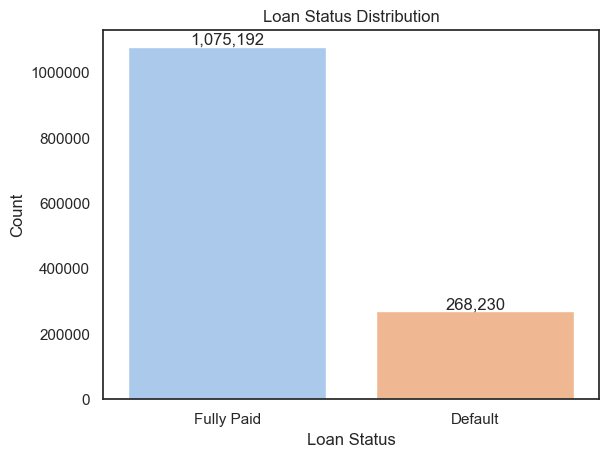

In [25]:
sns.set_theme(style='white', palette='pastel')

ax = sns.countplot(data=df, x='loan_status', hue='loan_status')
plt.ticklabel_format(style='plain', axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

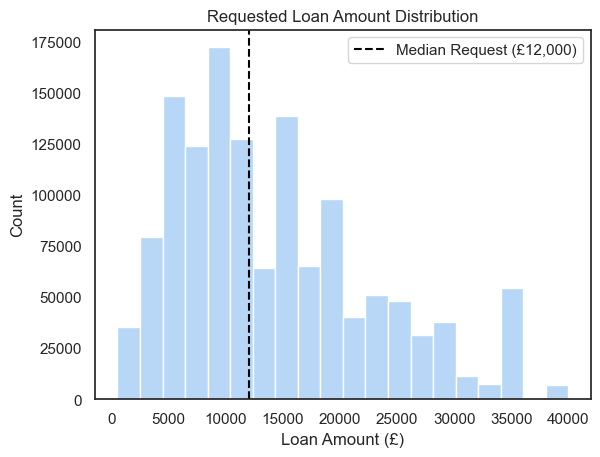

count    1343422.0
mean       14423.0
std         8716.0
min          500.0
25%         8000.0
50%        12000.0
75%        20000.0
max        40000.0
Name: loan_amnt, dtype: float64

In [26]:
sns.histplot(data=df, x='loan_amnt', bins=20)
plt.axvline(df['loan_amnt'].median(), c='black', ls='--', label=f'Median Request (£{df['loan_amnt'].median():,.0f})')
plt.title('Requested Loan Amount Distribution')
plt.xlabel('Loan Amount (£)')
plt.ylabel('Count')
plt.legend()
plt.show()

df['loan_amnt'].describe().round(0)

### Application Type

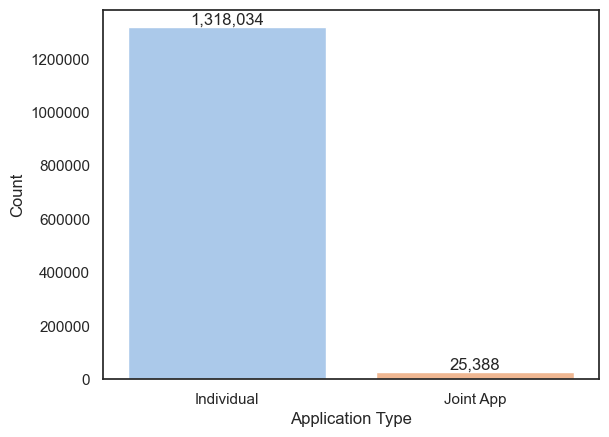

In [27]:
app_ax = sns.countplot(data=df, x='application_type', hue='application_type')
plt.ticklabel_format(style='plain', axis='y')

for container in app_ax.containers:
    app_ax.bar_label(container, fmt='{:,.0f}')

#plt.title('Application Type Distribution')
plt.xlabel('Application Type')
plt.ylabel('Count')
plt.show()

### Credit Score & Debt-to-Income

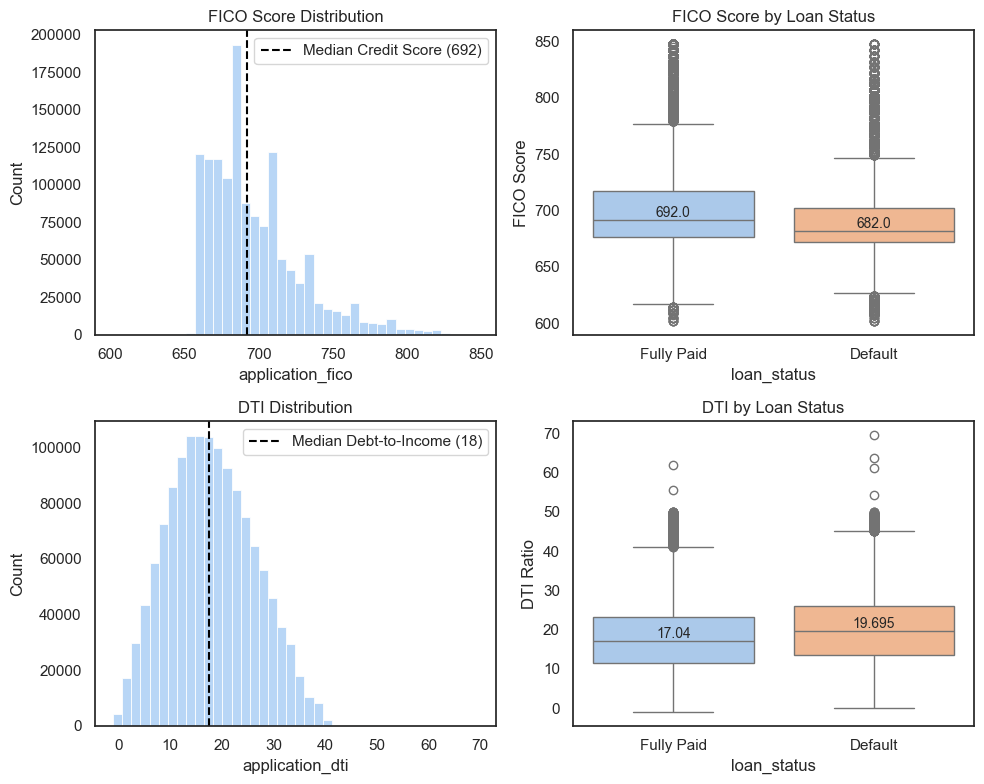

In [28]:
# FICO & DTI plots
plt.figure(figsize=(10, 8))

# FICO score plots
plt.subplot(2, 2, 1)
fico_median = df['application_fico'].median()
sns.histplot(data=df, x='application_fico', bins=40)
plt.axvline(fico_median, c='black', ls='--', label=f'Median Credit Score ({fico_median:,.0f})')
plt.title('FICO Score Distribution')
plt.ylabel('Count')
plt.legend()

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='loan_status', y='application_fico', hue='loan_status')
plt.title('FICO Score by Loan Status')
plt.ylabel('FICO Score')

ax_fico = plt.gca()
median_fico = df.groupby('loan_status')['application_fico'].median()
fico_labels = [t.get_text() for t in ax_fico.get_xticklabels()]
for i, label in enumerate(fico_labels):
    m = median_fico.get(label, np.nan)
    if pd.notna(m):
        ax_fico.text(i, m, m, ha='center', va='bottom', size='small')


# DTI plots
plt.subplot(2, 2, 3)
dti_median = df['application_dti'].median()
sns.histplot(data=df, x='application_dti', bins=40)
plt.axvline(dti_median, c='black', ls='--', label=f'Median Debt-to-Income ({dti_median:,.0f})')
plt.title('DTI Distribution')
plt.ylabel('Count')
plt.legend()

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='loan_status', y='application_dti', hue='loan_status')
plt.title('DTI by Loan Status')
plt.ylabel('DTI Ratio')

ax_dti = plt.gca()
median_dti = df.groupby('loan_status')['application_dti'].median()
dti_labels = [t.get_text() for t in ax_dti.get_xticklabels()]
for i, label in enumerate(dti_labels):
    m = median_dti.get(label, np.nan)
    if pd.notna(m):
        ax_dti.text(i, m, m, ha='center', va='bottom', size='small')

plt.tight_layout()
plt.show()

### Home Ownership

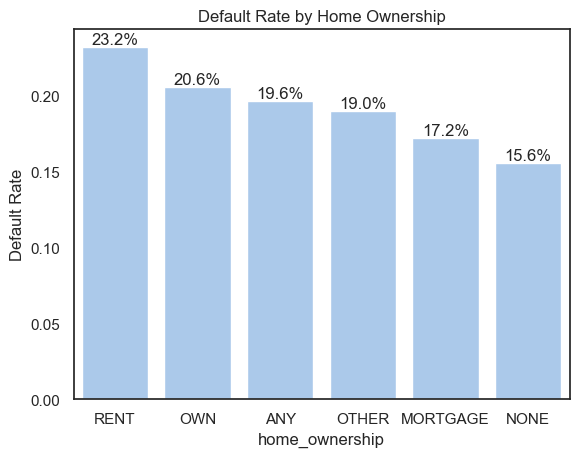

In [29]:
default_rate = (
    df.groupby('home_ownership')['loan_status']
      .apply(lambda x: (x == 'Default').mean())
      .sort_values(ascending=False)
)

hmo_ax = sns.barplot(default_rate)
hmo_ax.bar_label(hmo_ax.containers[0], fmt='{:.1%}')
plt.title('Default Rate by Home Ownership')
plt.ylabel('Default Rate')
plt.show()

In [30]:
home_ownership = df[df['home_ownership'].isin(['RENT', 'MORTGAGE', 'OWN'])].copy()

home_ownership['home_ownership'] = (
    home_ownership['home_ownership'].replace({
        'RENT': 'Rent', 
        'MORTGAGE': 'Mortgage', 
        'OWN': 'Own'
    })
)

paid_ownership = (
    (home_ownership[home_ownership['loan_status'] == 'Fully Paid'])
    .groupby('home_ownership')['home_ownership'].count()
).reset_index(name='count')

deafult_ownership = (
    (home_ownership[home_ownership['loan_status'] == 'Default'])
    .groupby('home_ownership')['home_ownership'].count()
).reset_index(name='count')

print(f'{paid_ownership}\n')
print(f'{deafult_ownership}')

  home_ownership   count
0       Mortgage  550276
1            Own  114808
2           Rent  409726

  home_ownership   count
0       Mortgage  114395
1            Own   29816
2           Rent  123929


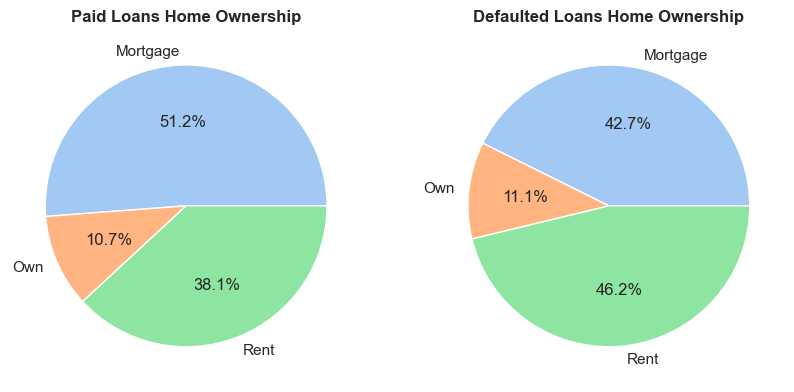

In [31]:
plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.pie(paid_ownership['count'], labels=paid_ownership['home_ownership'], autopct='%1.1f%%')
plt.title('Paid Loans Home Ownership', weight='bold')

plt.subplot(1, 2, 2)
plt.pie(deafult_ownership['count'], labels=deafult_ownership['home_ownership'], autopct='%1.1f%%')
plt.title('Defaulted Loans Home Ownership', weight='bold')

plt.show()

### Employment

In [32]:
emp_order = [
    '< 1 year', '1 year', '2 years', '3 years', '4 years', 
    '5 years', '6 years', '7 years', '8 years', '9 years', 
    '10+ years', 'Unknown'
]

df['emp_length'] = pd.Categorical(df['emp_length'], categories=emp_order, ordered=True)

df['emp_length'].value_counts()

emp_length
10+ years    441818
2 years      121599
< 1 year     107790
3 years      107480
1 year        88334
5 years       84075
4 years       80469
Unknown       78109
6 years       62661
8 years       60637
7 years       59561
9 years       50889
Name: count, dtype: int64

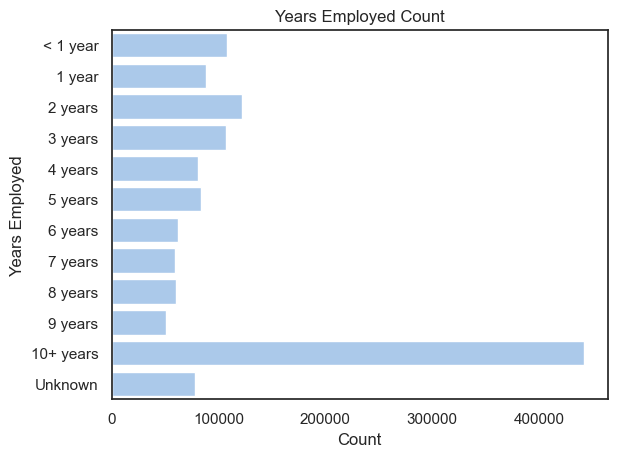

In [33]:
sns.countplot(data=df['emp_length'])
plt.title('Years Employed Count')
plt.ylabel('Years Employed')
plt.xlabel('Count')
plt.show()

In [34]:
emp_default_rate = (
    df.groupby('emp_length', observed=False)['loan_status']
      .apply(lambda x: (x == 'Default').mean())
      .reset_index(name='default_rate')
)

emp_default_rate['emp_length'] = emp_default_rate['emp_length'].str.strip(' years')

emp_default_rate

,emp_length,default_rate
0,< 1,0.205390
1,1,0.205629
2,2,0.198151
3,3,0.199786
4,4,0.197331
5,5,0.195992
6,6,0.193549
7,7,0.194960
8,8,0.199400
9,9,0.199080


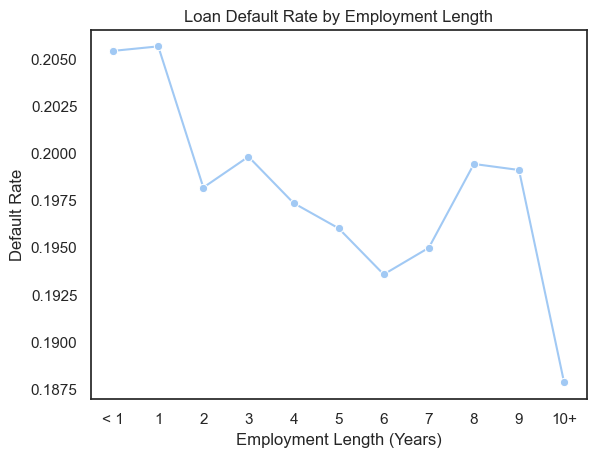

In [35]:
known_emplength = emp_default_rate[emp_default_rate['emp_length'] != 'Unknown'].copy()

sns.lineplot(data=known_emplength, x='emp_length', y='default_rate', marker='o')
plt.title('Loan Default Rate by Employment Length')
plt.xlabel('Employment Length (Years)')
plt.ylabel('Default Rate')
plt.show()

In [36]:
unknown_emplength = df[df['emp_length'] == 'Unknown'].copy()
unknown_count = unknown_emplength['loan_status'].value_counts() 

unknown_count

loan_status
Fully Paid    57056
Default       21053
Name: count, dtype: int64

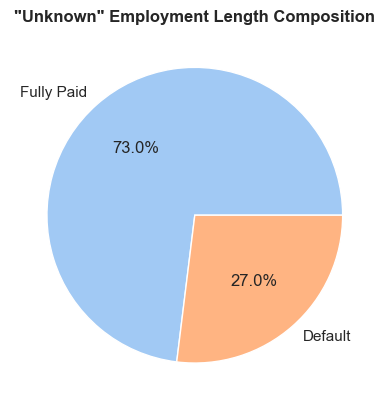

In [37]:
plt.pie(unknown_count, labels=unknown_count.index, autopct='%1.1f%%')
plt.title('"Unknown" Employment Length Composition', weight='bold')
plt.show()

### Loan Purpose

In [38]:
purpose_count = df['purpose'].value_counts()
purpose_count

purpose
debt_consolidation    779474
credit_card           295031
home_improvement       87311
other                  77597
major_purchase         29360
medical                15514
small_business         15349
car                    14551
moving                  9447
vacation                9039
house                   7239
wedding                 2273
renewable_energy         932
educational              305
Name: count, dtype: int64

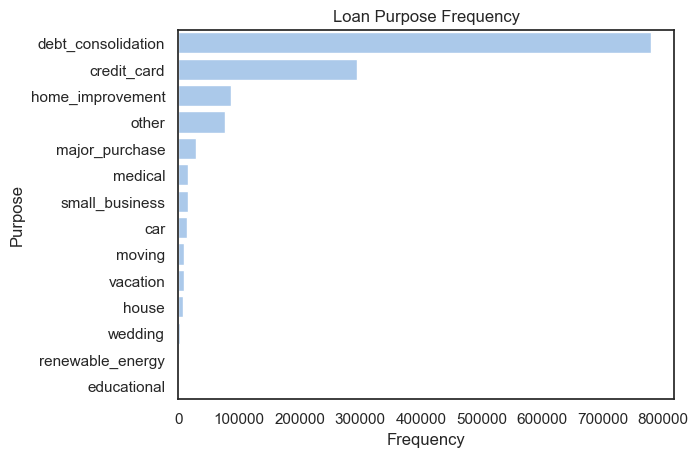

In [39]:
sns.countplot(data=df['purpose'], order=df['purpose'].value_counts().index)
plt.title('Loan Purpose Frequency')
plt.ylabel('Purpose')
plt.xlabel('Frequency')
plt.show()

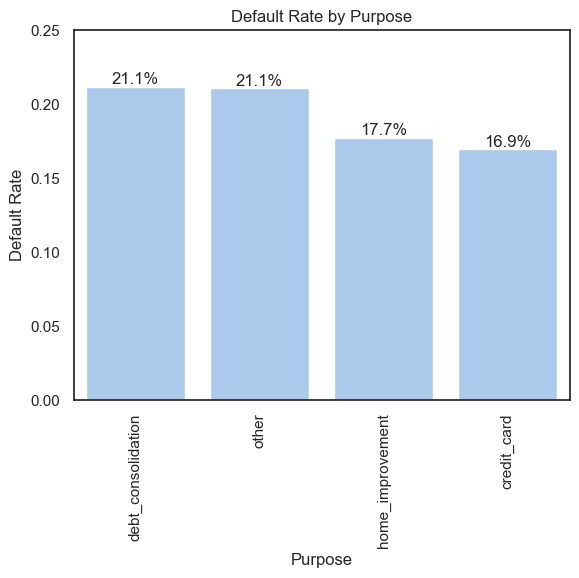

In [40]:
top_purpose = df[df['purpose'].isin(['debt_consolidation', 'credit_card', 'home_improvement', 'other'])].copy()

top_purpose_default_rate = (
    top_purpose.groupby('purpose', observed=False)['loan_status']
      .apply(lambda x: (x == 'Default').mean())
      .reset_index(name='default_rate')
).sort_values(by='default_rate', ascending=False)

top_pur_ax = sns.barplot(top_purpose_default_rate, x='purpose', y='default_rate')
top_pur_ax.bar_label(top_pur_ax.containers[0], fmt='{:.1%}')
plt.title('Default Rate by Purpose')
plt.ylabel('Default Rate')
plt.xlabel('Purpose')
plt.xticks(rotation=90)
plt.ylim(0, 0.25)
plt.show()

### Loan Grade

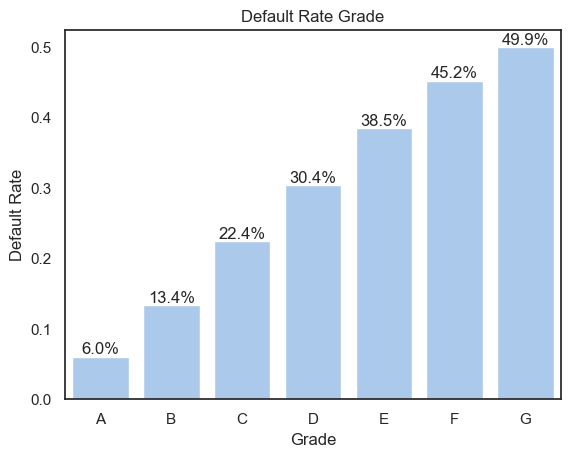

In [41]:
grade_default_rate = (
    df.groupby('grade', observed=False)['loan_status']
      .apply(lambda x: (x == 'Default').mean())
      .reset_index(name='default_rate')
)

grade_ax = sns.barplot(grade_default_rate, x='grade', y='default_rate')
grade_ax.bar_label(grade_ax.containers[0], fmt='{:.1%}')
plt.title('Default Rate Grade')
plt.ylabel('Default Rate')
plt.xlabel('Grade')
plt.ylim()
plt.show()

In [42]:
grade_default_rate

,grade,default_rate
0,A,0.060441
1,B,0.133896
2,C,0.224456
3,D,0.303910
4,E,0.384957
5,F,0.452077
6,G,0.499396


### Credit History

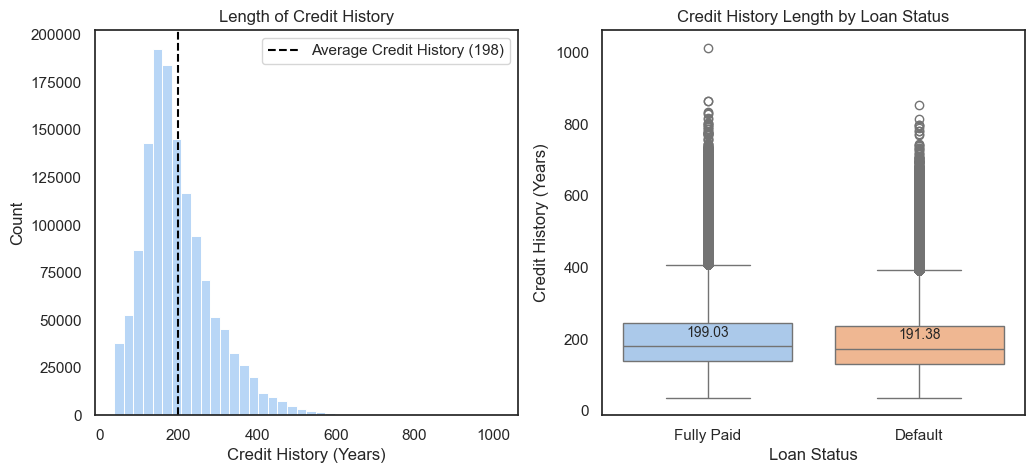

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
mean_credhit = df['credit_history_months'].mean()
sns.histplot(data=df, x='credit_history_months', bins=40)
plt.axvline(mean_credhit, c='black', ls='--', label=f'Average Credit History ({mean_credhit:,.0f})')
plt.title('Length of Credit History')
plt.xlabel('Credit History (Years)')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='loan_status', y='credit_history_months', hue='loan_status')
plt.title('Credit History Length by Loan Status')
plt.ylabel('Credit History (Years)')
plt.xlabel('Loan Status')

ax_credhist = plt.gca()
avg_credhist = df.groupby('loan_status')['credit_history_months'].mean().round(2)
credhist_labels = [t.get_text() for t in ax_credhist.get_xticklabels()]
for i, label in enumerate(credhist_labels):
    m = avg_credhist.get(label, np.nan)
    if pd.notna(m):
        ax_credhist.text(i, m, m, ha='center', va='bottom', size='small')

plt.show()

### Temporal Analysis

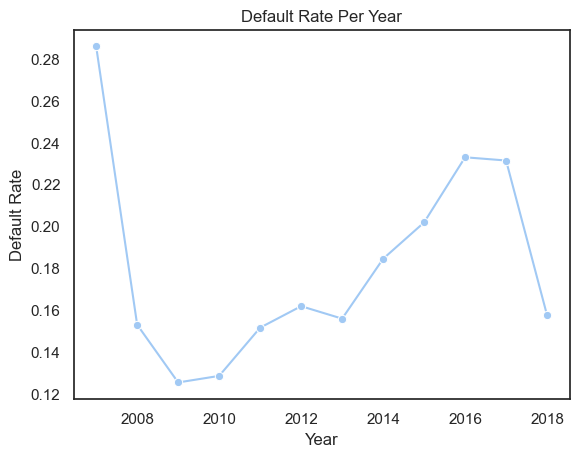

In [44]:
# extract year only
df['issue_d'] = df['issue_d'].dt.year

yearly_default_rate = (
    df.groupby('issue_d')['loan_status']
      .apply(lambda x: (x == 'Default').mean())
      .reset_index(name='default_rate')
)

sns.lineplot(data=yearly_default_rate, x='issue_d', y='default_rate', marker='o')
plt.title('Default Rate Per Year')
plt.xlabel('Year')
plt.ylabel('Default Rate')
plt.show()

### Correlation

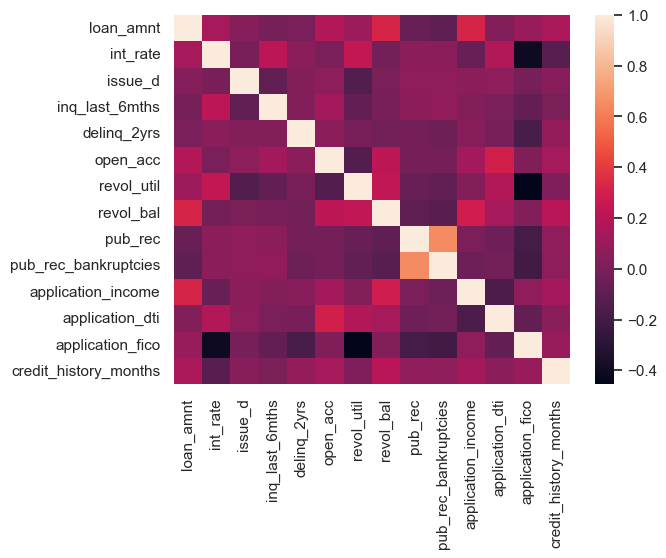

In [45]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

In [46]:
corr_matrix = df.corr(numeric_only=True).abs()
threshold = 0.60
high_corr_list = []

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col1 = columns[i]
        col2 = columns[j]
        val = corr_matrix.loc[col1, col2]
        
        if val >= threshold:
            high_corr_list.append({'Feature 1': col1, 'Feature 2': col2, 'Correlation': val})

high_corr_df = pd.DataFrame(high_corr_list).sort_values(by='Correlation', ascending=False)
print(high_corr_df)

  Feature 1             Feature 2  Correlation
0   pub_rec  pub_rec_bankruptcies     0.649617


In [47]:
df = df.drop(columns=['pub_rec'])

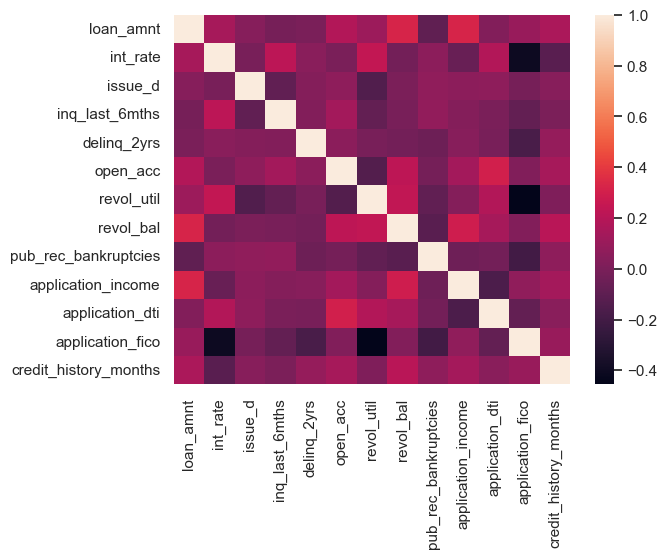

In [48]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1343422 entries, 0 to 2260697
Data columns (total 22 columns):
 #   Column                    Non-Null Count    Dtype   
---  ------                    --------------    -----   
 0   id                        1343422 non-null  object  
 1   application_type          1343422 non-null  object  
 2   loan_amnt                 1343422 non-null  float64 
 3   term                      1343422 non-null  object  
 4   purpose                   1343422 non-null  object  
 5   int_rate                  1343422 non-null  float64 
 6   grade                     1343422 non-null  object  
 7   emp_length                1343422 non-null  category
 8   home_ownership            1343422 non-null  object  
 9   issue_d                   1343422 non-null  int32   
 10  inq_last_6mths            1343422 non-null  float64 
 11  delinq_2yrs               1343422 non-null  float64 
 12  open_acc                  1343422 non-null  float64 
 13  revol_util       

In [50]:
df.columns.to_list()

['id',
 'application_type',
 'loan_amnt',
 'term',
 'purpose',
 'int_rate',
 'grade',
 'emp_length',
 'home_ownership',
 'issue_d',
 'inq_last_6mths',
 'delinq_2yrs',
 'open_acc',
 'revol_util',
 'revol_bal',
 'pub_rec_bankruptcies',
 'loan_status',
 'application_income',
 'application_dti',
 'application_verification',
 'application_fico',
 'credit_history_months']

### Save Dataset

In [51]:
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/pd_dataset.csv', index=False)